# Model 2: Vision Transformer (ViT) - Attention-Based Architecture
## Kiến trúc dựa trên cơ chế Attention và Transfer Learning

### 1. Cài đặt thư viện

In [1]:
import sys, subprocess

# Cài đặt timm library cho Vision Transformer
packages = ["timm", "matplotlib", "numpy", "pandas", "seaborn", "tqdm", "pillow"]
subprocess.check_call([sys.executable, "-m", "pip", "install"] + packages)

print("\n[OK] Cài đặt thư viện xong!")


[OK] Cài đặt thư viện xong!


### 2. Import và Cấu hình chung

In [2]:
import os
import random
import warnings
from collections import Counter
from tqdm import tqdm
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import torchvision.models as models

# Timm library cho Vision Transformer
import timm
from timm.models import vision_transformer

warnings.filterwarnings('ignore')

# Cấu hình
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# Cấu hình hiển thị
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [14, 6]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Thiết bị sử dụng: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")
else:
    print("Sử dụng CPU")

Thiết bị sử dụng: cuda
GPU: NVIDIA GeForce GTX 1650
CUDA Version: 12.1


### 3. Cấu hình đường dẫn và hyperparameters

In [3]:
# Hyperparameters cho Vision Transformer
IMG_SIZE = 224           # Vision Transformer yêu cầu ảnh vuông
PATCH_SIZE = 16          # Kích thước patch (16x16)
BATCH_SIZE = 32          # Batch size (nhỏ hơn ResNet vì ViT tốn nhiều bộ nhớ)
NUM_EPOCHS = 10
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
RANDOM_STATE = 42
MODEL_SAVE_PATH = "best_model_vit.pth"

print(f"\nImage size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Patch size: {PATCH_SIZE}x{PATCH_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Number of epochs: {NUM_EPOCHS}")


Image size: 224x224
Patch size: 16x16
Batch size: 32
Number of epochs: 10


### 4. Chuẩn bị dữ liệu

In [4]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. Định nghĩa bộ Augmentation/Transforms phù hợp với mô hình Vision Transformer (ViT)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),       # ViT mặc định nhận kích thước 224x224
    transforms.RandomHorizontalFlip(),   # Tăng cường dữ liệu bằng cách lật ảnh ngẫu nhiên
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Chuẩn hóa theo ImageNet
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),       # Không lật/xoay ảnh khi val/test
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. KHAI BÁO ĐƯỜNG DẪN GỐC (Thay đổi đường dẫn này đúng với máy hoặc Google Drive của bạn)
# Đường dẫn phải trỏ thẳng đến nơi chứa 3 thư mục lớn: train, val, test
data_dir = r'C:\DL' 

train_dir = os.path.join(data_dir, 'train')
val_dir = os.path.join(data_dir, 'val')
test_dir = os.path.join(data_dir, 'test')

# 3. Sử dụng ImageFolder (Tự động đọc các folder 0, 1, 2... làm nhãn tương ứng)
train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(root=val_dir, transform=val_test_transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=val_test_transform)

# 4. Khởi tạo DataLoaders để nạp dữ liệu theo batch vào model
batch_size = 32  # Bạn có thể điều chỉnh 16, 32 hoặc 64 tùy theo VRAM của GPU
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

# 5. Kiểm tra thông tin kết quả đọc dữ liệu
num_classes = len(train_dataset.classes)
print(f"✓ Tìm thấy tổng cộng {num_classes} lớp (classes): {train_dataset.classes}")
print(f"📌 Số lượng ảnh Train: {len(train_dataset)}")
print(f"📌 Số lượng ảnh Validation: {len(val_dataset)}")
print(f"📌 Số lượng ảnh Test: {len(test_dataset)}")

✓ Tìm thấy tổng cộng 45 lớp (classes): ['aloevera', 'banana', 'bilimbi', 'butterfly', 'cantaloupe', 'cassava', 'cat', 'cats', 'coconut', 'corn', 'cow', 'cucumber', 'curcuma', 'dog', 'dogs', 'eggplant', 'elephant', 'galangal', 'ginger', 'guava', 'hen', 'horse', 'kale', 'lion', 'longbeans', 'mango', 'melon', 'monkey', 'orange', 'paddy', 'panda', 'papaya', 'peperchili', 'pineapple', 'pomelo', 'shallot', 'sheep', 'soybeans', 'spider', 'spinach', 'squirrel', 'sweetpotatoes', 'tobacco', 'waterapple', 'watermelon']
📌 Số lượng ảnh Train: 42446
📌 Số lượng ảnh Validation: 6079
📌 Số lượng ảnh Test: 12126


### 5. Định nghĩa Dataset Custom

In [5]:
class TestImageDataset(Dataset):
    """Custom Dataset cho test images với labels từ CSV"""
    def __init__(self, csv_path, image_dir, transform=None, class_to_idx=None):
        self.df = pd.read_csv(csv_path)
        self.image_dir = image_dir
        self.transform = transform
        self.class_to_idx = class_to_idx

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_name = str(row["Image_ID"])
        label_name = row["Label"]

        # Tìm đường dẫn ảnh (thử các extension khác nhau)
        possible_paths = [
            os.path.join(self.image_dir, image_name),
            os.path.join(self.image_dir, image_name + ".jpg"),
            os.path.join(self.image_dir, image_name + ".jpeg"),
            os.path.join(self.image_dir, image_name + ".png")
        ]

        image_path = None
        for path in possible_paths:
            if os.path.exists(path):
                image_path = path
                break

        if image_path is None:
            raise FileNotFoundError(f"Không tìm thấy ảnh: {image_name}")

        image = Image.open(image_path).convert("RGB")
        label = self.class_to_idx[label_name]

        if self.transform:
            image = self.transform(image)

        return image, label

print("Dataset class đã được định nghĩa")

Dataset class đã được định nghĩa


### 6. Load và khám phá dữ liệu

In [6]:
# Load raw training dataset
raw_train_dataset = datasets.ImageFolder(str(train_dir))

class_names = raw_train_dataset.classes
num_classes = len(class_names)
class_to_idx = raw_train_dataset.class_to_idx

print(f"Số lượng lớp: {num_classes}")
print(f"Danh sách lớp: {class_names}")
print(f"Số ảnh train: {len(raw_train_dataset)}")
print(f"\nClass to index mapping:")
for cls, idx in sorted(class_to_idx.items()):
    print(f"  {cls}: {idx}")

Số lượng lớp: 45
Danh sách lớp: ['aloevera', 'banana', 'bilimbi', 'butterfly', 'cantaloupe', 'cassava', 'cat', 'cats', 'coconut', 'corn', 'cow', 'cucumber', 'curcuma', 'dog', 'dogs', 'eggplant', 'elephant', 'galangal', 'ginger', 'guava', 'hen', 'horse', 'kale', 'lion', 'longbeans', 'mango', 'melon', 'monkey', 'orange', 'paddy', 'panda', 'papaya', 'peperchili', 'pineapple', 'pomelo', 'shallot', 'sheep', 'soybeans', 'spider', 'spinach', 'squirrel', 'sweetpotatoes', 'tobacco', 'waterapple', 'watermelon']
Số ảnh train: 42446

Class to index mapping:
  aloevera: 0
  banana: 1
  bilimbi: 2
  butterfly: 3
  cantaloupe: 4
  cassava: 5
  cat: 6
  cats: 7
  coconut: 8
  corn: 9
  cow: 10
  cucumber: 11
  curcuma: 12
  dog: 13
  dogs: 14
  eggplant: 15
  elephant: 16
  galangal: 17
  ginger: 18
  guava: 19
  hen: 20
  horse: 21
  kale: 22
  lion: 23
  longbeans: 24
  mango: 25
  melon: 26
  monkey: 27
  orange: 28
  paddy: 29
  panda: 30
  papaya: 31
  peperchili: 32
  pineapple: 33
  pomelo: 34


### 7. Phân tích phân bố lớp

,Class,Count
16,elephant,2924
21,horse,2909
6,cat,1915
23,lion,1872
13,dog,1838
14,dogs,1019
7,cats,1019
3,butterfly,1016
20,hen,1016
40,squirrel,1016


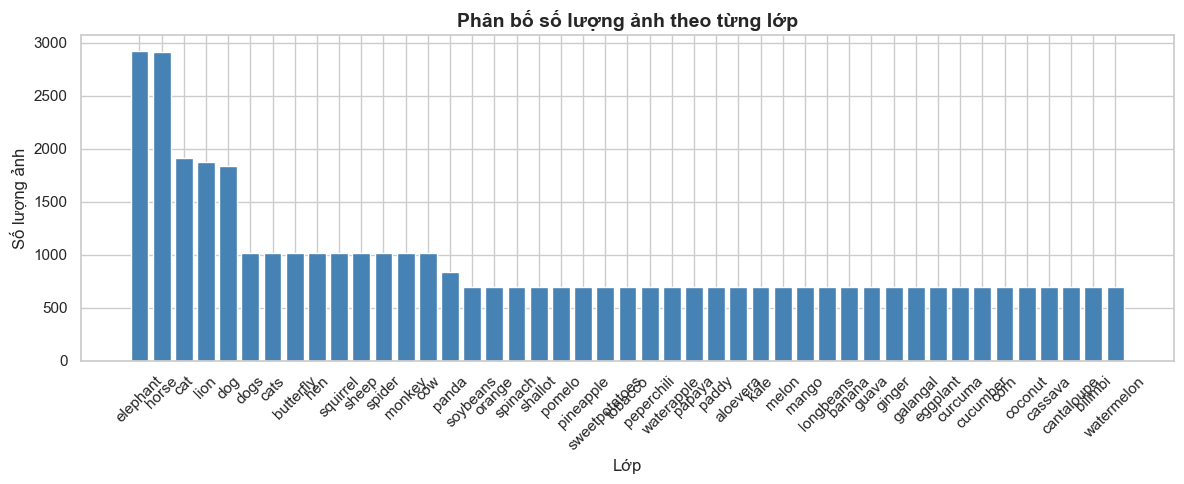


Tổng cộng: 42446 ảnh


In [7]:
class_counts = Counter(raw_train_dataset.targets)

class_distribution_df = pd.DataFrame({
    "Class": [class_names[i] for i in class_counts.keys()],
    "Count": list(class_counts.values())
}).sort_values("Count", ascending=False)

display(class_distribution_df)

plt.figure(figsize=(12, 5))
plt.bar(class_distribution_df["Class"], class_distribution_df["Count"], color='steelblue')
plt.xticks(rotation=45)
plt.title("Phân bố số lượng ảnh theo từng lớp", fontsize=14, fontweight='bold')
plt.xlabel("Lớp")
plt.ylabel("Số lượng ảnh")
plt.tight_layout()
plt.show()

print(f"\nTổng cộng: {class_distribution_df['Count'].sum()} ảnh")

### 8. Tạo DataLoaders

In [8]:
# Tạo train dataset với augmentation
train_dataset = datasets.ImageFolder(str(train_dir), transform=train_transform)
test_dataset = datasets.ImageFolder(str(test_dir))

# Tạo DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,
    pin_memory=True if torch.cuda.is_available() else False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True if torch.cuda.is_available() else False
)

print(f"Train dataset: {len(train_dataset)} ảnh")
print(f"Test dataset: {len(test_dataset)} ảnh")
print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Train dataset: 42446 ảnh
Test dataset: 12126 ảnh
Train batches: 1327
Test batches: 379


### 9. Hiển thị sample ảnh

Batch shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Sample labels: [5, 23, 34, 13, 15, 26, 27, 39]


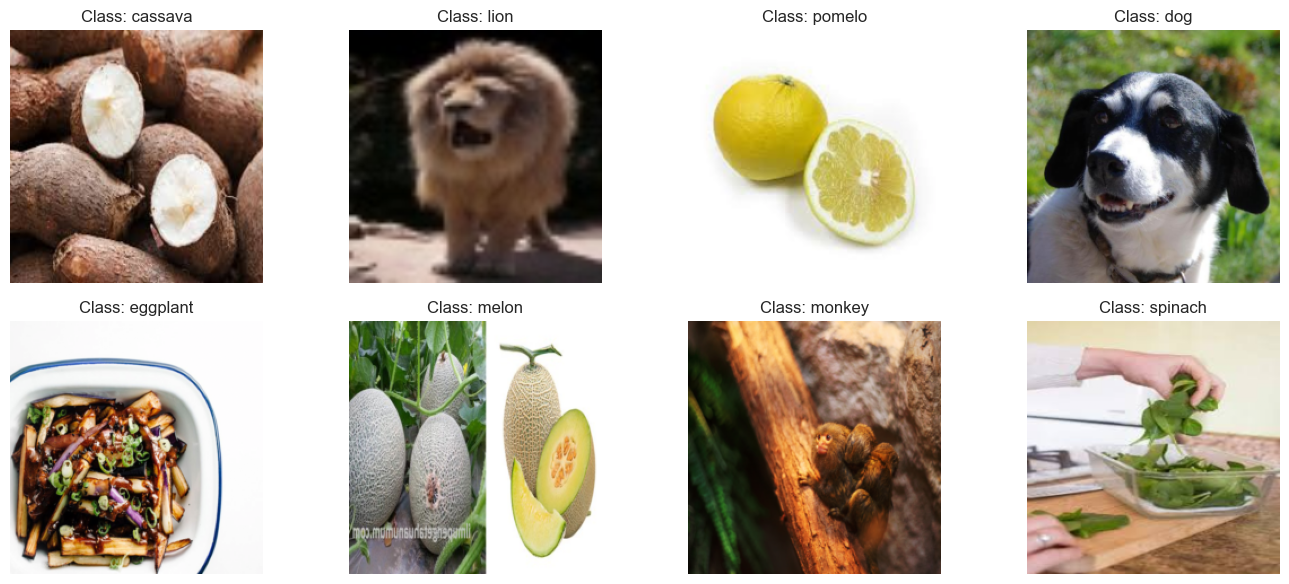

In [9]:
# Lấy một batch để kiểm tra
sample_batch, sample_labels = next(iter(train_loader))

print(f"Batch shape: {sample_batch.shape}")
print(f"Labels shape: {sample_labels.shape}")
print(f"Sample labels: {sample_labels[:8].tolist()}")

# Reverse normalization để hiển thị
def denormalize(img):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (img * std + mean).clamp(0, 1)

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for idx, ax in enumerate(axes.flat):
    img = denormalize(sample_batch[idx])
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title(f"Class: {class_names[sample_labels[idx]]}")
    ax.axis('off')

plt.tight_layout()
plt.show()

### 10. Định nghĩa Vision Transformer Model
Sử dụng Pre-trained Vision Transformer từ TIMM library

In [10]:
def create_vit_model(num_classes, model_name='vit_base_patch16_224', pretrained=True):
    """
    Tạo Vision Transformer model với Transfer Learning
    
    Args:
        num_classes: Số lượng lớp phân loại
        model_name: Tên architecture ViT từ TIMM
        pretrained: Sử dụng pre-trained weights từ ImageNet
    
    Returns:
        model: Vision Transformer model
    """
    # Load pre-trained ViT từ TIMM
    model = timm.create_model(
        model_name,
        pretrained=pretrained,
        num_classes=num_classes,
        in_chans=3
    )
    
    return model

# Tạo model
print("Đang load Vision Transformer model...")
model = create_vit_model(num_classes, model_name='vit_base_patch16_224', pretrained=True)
model = model.to(device)

print(f"\nModel: Vision Transformer (ViT-Base)")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Đang load Vision Transformer model...

Model: Vision Transformer (ViT-Base)
Total parameters: 85,833,261
Trainable parameters: 85,833,261


### 11. Cấu hình Training

In [11]:
# Loss function
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Optimizer với learning rate scheduler
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# Learning rate scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

print("Loss function: CrossEntropyLoss (với label smoothing = 0.1)")
print(f"Optimizer: AdamW (lr={LEARNING_RATE}, weight_decay={WEIGHT_DECAY})")
print(f"Scheduler: CosineAnnealingLR")

Loss function: CrossEntropyLoss (với label smoothing = 0.1)
Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
Scheduler: CosineAnnealingLR


### 12. Hàm Training

In [12]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    """
    Huấn luyện mô hình cho 1 epoch
    """
    if torch.cuda.is_available():
        device = torch.device('cuda')
    model.train()
    model = model.to(device)
    
    total_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(train_loader, desc="Training", leave=False)
    
    for images, labels in progress_bar:
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Gradient clipping
        optimizer.step()

        # Tính accuracy
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        total_loss += loss.item()

        progress_bar.set_postfix({'Loss': f'{loss.item():.4f}'})

    avg_loss = total_loss / len(train_loader)
    avg_accuracy = correct / total

    return avg_loss, avg_accuracy

print("Hàm train_epoch đã được định nghĩa")

Hàm train_epoch đã được định nghĩa


### 13. Hàm Validation

In [13]:
def validate(model, test_loader, criterion, device):
    """
    Đánh giá mô hình trên tập test
    """
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(test_loader, desc="Validating", leave=False)

    with torch.no_grad():
        for images, labels in progress_bar:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            total_loss += loss.item()

            progress_bar.set_postfix({'Loss': f'{loss.item():.4f}'})

    avg_loss = total_loss / len(test_loader)
    avg_accuracy = correct / total

    return avg_loss, avg_accuracy

print("Hàm validate đã được định nghĩa")

Hàm validate đã được định nghĩa


### 14. Huấn luyện mô hình

In [ ]:
import os
import torch

# 1. Khởi tạo dictionary lưu lịch sử huấn luyện
history = {
    'train_loss': [],
    'train_accuracy': [],
    'val_loss': [],
    'val_accuracy': []
}

best_val_accuracy = 0.0
best_model_state = None

# Đảm bảo MODEL_SAVE_PATH đã được định nghĩa, nếu chưa có hãy bỏ comment dòng dưới:
# MODEL_SAVE_PATH = 'best_vit_model.pth'

# 2. Khởi tạo Learning Rate Scheduler (nếu ở các cell trước bạn chưa định nghĩa)
# Nếu bạn đã khai báo 'scheduler' ở cell trước rồi thì có thể xóa hoặc comment 2 dòng dưới đi nhé
if 'scheduler' not in locals():
    from torch.optim.lr_scheduler import ExponentialLR
    scheduler = ExponentialLR(optimizer, gamma=0.9)

print(f"{'='*70}")
print(f"{'Epoch':<6} {'Train Loss':<12} {'Train Acc':<12} {'Val Loss':<12} {'Val Acc':<12}")
print(f"{'='*70}")

# 3. Vòng lặp Huấn luyện và Đánh giá qua từng Epoch
for epoch in range(NUM_EPOCHS):
    
    # --- GIAI ĐOẠN TRAIN ---
    # Sử dụng train_loader đã tạo tự động từ ImageFolder
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # --- GIAI ĐOẠN VALIDATION ---
    # SỬA LỖI: Truyền đúng 'val_loader' thay vì 'test_loader' vào hàm validate
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    
    # Cập nhật Learning rate sau mỗi epoch
    scheduler.step()
    
    # Lưu kết quả vào lịch sử (history)
    history['train_loss'].append(train_loss)
    history['train_accuracy'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_accuracy'].append(val_acc)
    
    # KIỂM TRA VÀ LƯU MÔ HÌNH TỐT NHẤT (BEST MODEL)
    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        best_model_state = model.state_dict().copy()
        torch.save(best_model_state, MODEL_SAVE_PATH)
        best_indicator = " ← BEST"
    else:
        best_indicator = ""
    
    # In kết quả của epoch hiện tại
    print(f"{epoch+1:<6} {train_loss:<12.4f} {train_acc:<12.4f} {val_loss:<12.4f} {val_acc:<12.4f}{best_indicator}")

print(f"{'='*70}")
print(f"\nHoàn tất huấn luyện!")
print(f"Best validation accuracy: {best_val_accuracy:.4f}")
print(f"Mô hình tối ưu đã được lưu tại: {MODEL_SAVE_PATH}")

Epoch  Train Loss   Train Acc    Val Loss     Val Acc     


Training:   0%|          | 0/1327 [00:00<?, ?it/s]

Training:   2%|▏         | 33/1327 [08:36<5:56:35, 16.53s/it, Loss=1.7261]

### 15. Vẽ biểu đồ Training History

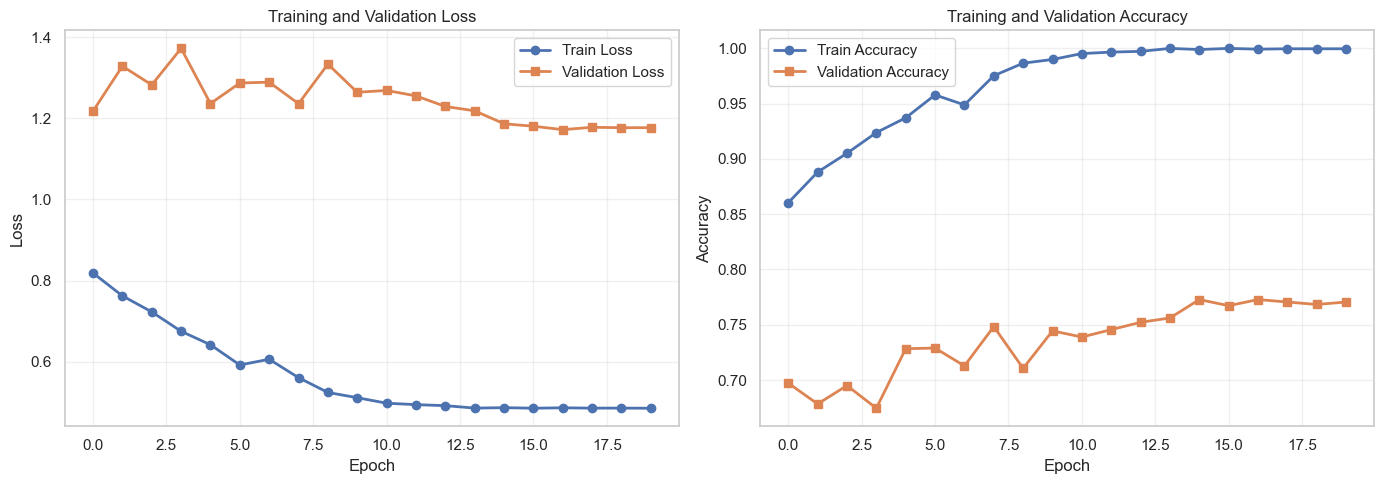


Final training accuracy: 0.9997
Final validation accuracy: 0.7706


In [ ]:
# Vẽ biểu đồ Loss
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(history['train_loss'], label='Train Loss', marker='o', linewidth=2)
axes[0].plot(history['val_loss'], label='Validation Loss', marker='s', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curve
axes[1].plot(history['train_accuracy'], label='Train Accuracy', marker='o', linewidth=2)
axes[1].plot(history['val_accuracy'], label='Validation Accuracy', marker='s', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal training accuracy: {history['train_accuracy'][-1]:.4f}")
print(f"Final validation accuracy: {history['val_accuracy'][-1]:.4f}")

### 16. Load Best Model và Final Evaluation

In [ ]:
# Load best model
model.load_state_dict(best_model_state)
model.eval()

# Đánh giá trên test set
test_loss, test_accuracy = validate(model, test_loader, criterion, device)

print(f"\n{'='*50}")
print(f"Final Test Results (Best Model):")
print(f"{'='*50}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"{'='*50}")


Final Test Results (Best Model):
Test Loss: 1.1769
Test Accuracy: 0.7706


### 17. Chi tiết Predictions

In [ ]:
# Lấy predictions cho từng lớp
model.eval()

all_predictions = []
all_targets = []
all_probabilities = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Getting predictions"):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probabilities = torch.softmax(outputs, dim=1)
        _, predictions = torch.max(outputs, 1)

        all_predictions.extend(predictions.cpu().numpy())
        all_targets.extend(labels.cpu().numpy())
        all_probabilities.extend(probabilities.cpu().numpy())

all_predictions = np.array(all_predictions)
all_targets = np.array(all_targets)
all_probabilities = np.array(all_probabilities)

print(f"Predictions shape: {all_predictions.shape}")
print(f"Targets shape: {all_targets.shape}")

Getting predictions: 100%|██████████| 113/113 [01:07<00:00,  1.67it/s]

Predictions shape: (1800,)
Targets shape: (1800,)


### 18. Confusion Matrix

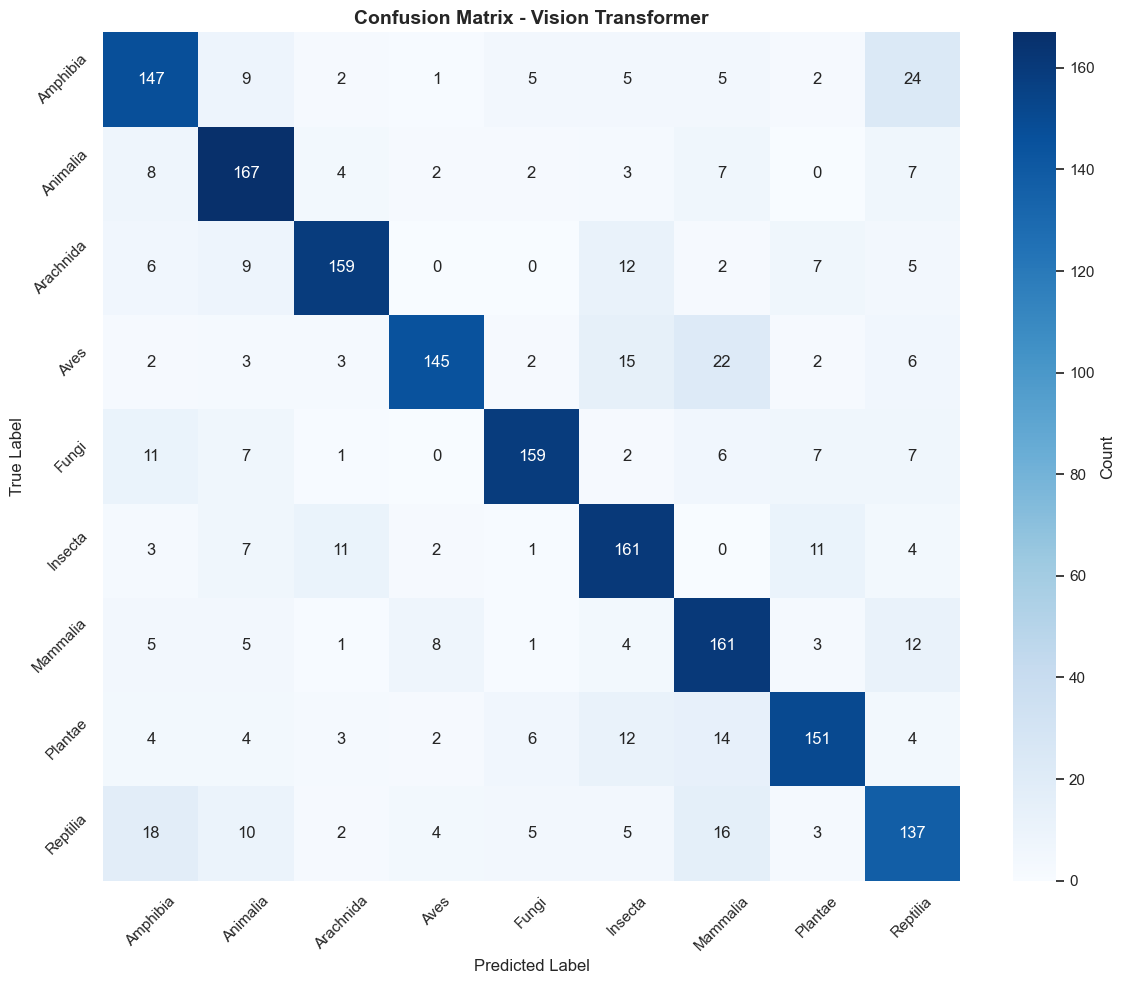

Confusion matrix plotted successfully!


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Tính confusion matrix
cm = confusion_matrix(all_targets, all_predictions)

# Vẽ confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Vision Transformer', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

print("Confusion matrix plotted successfully!")

### 19. Classification Report

In [ ]:
# Classification report
report = classification_report(
    all_targets, all_predictions, 
    target_names=class_names,
    digits=4
)

print("\n" + "="*80)
print("CLASSIFICATION REPORT - Vision Transformer")
print("="*80)
print(report)

# Per-class accuracy
print("\n" + "="*80)
print("Per-Class Accuracy:")
print("="*80)

for i, class_name in enumerate(class_names):
    mask = all_targets == i
    if mask.sum() > 0:
        accuracy = (all_predictions[mask] == all_targets[mask]).mean()
        print(f"{class_name:<15} : {accuracy:.4f}")


CLASSIFICATION REPORT - Vision Transformer
              precision    recall  f1-score   support

    Amphibia     0.7206    0.7350    0.7277       200
    Animalia     0.7557    0.8350    0.7933       200
   Arachnida     0.8548    0.7950    0.8238       200
        Aves     0.8841    0.7250    0.7967       200
       Fungi     0.8785    0.7950    0.8346       200
     Insecta     0.7352    0.8050    0.7685       200
    Mammalia     0.6910    0.8050    0.7436       200
     Plantae     0.8118    0.7550    0.7824       200
    Reptilia     0.6650    0.6850    0.6749       200

    accuracy                         0.7706      1800
   macro avg     0.7774    0.7706    0.7717      1800
weighted avg     0.7774    0.7706    0.7717      1800


Per-Class Accuracy:
Amphibia        : 0.7350
Animalia        : 0.8350
Arachnida       : 0.7950
Aves            : 0.7250
Fungi           : 0.7950
Insecta         : 0.8050
Mammalia        : 0.8050
Plantae         : 0.7550
Reptilia        : 0.6850


### 20. Visualization - Correct vs Incorrect Predictions

Total predictions: 1800
Correct predictions: 1387 (77.06%)
Incorrect predictions: 413 (22.94%)


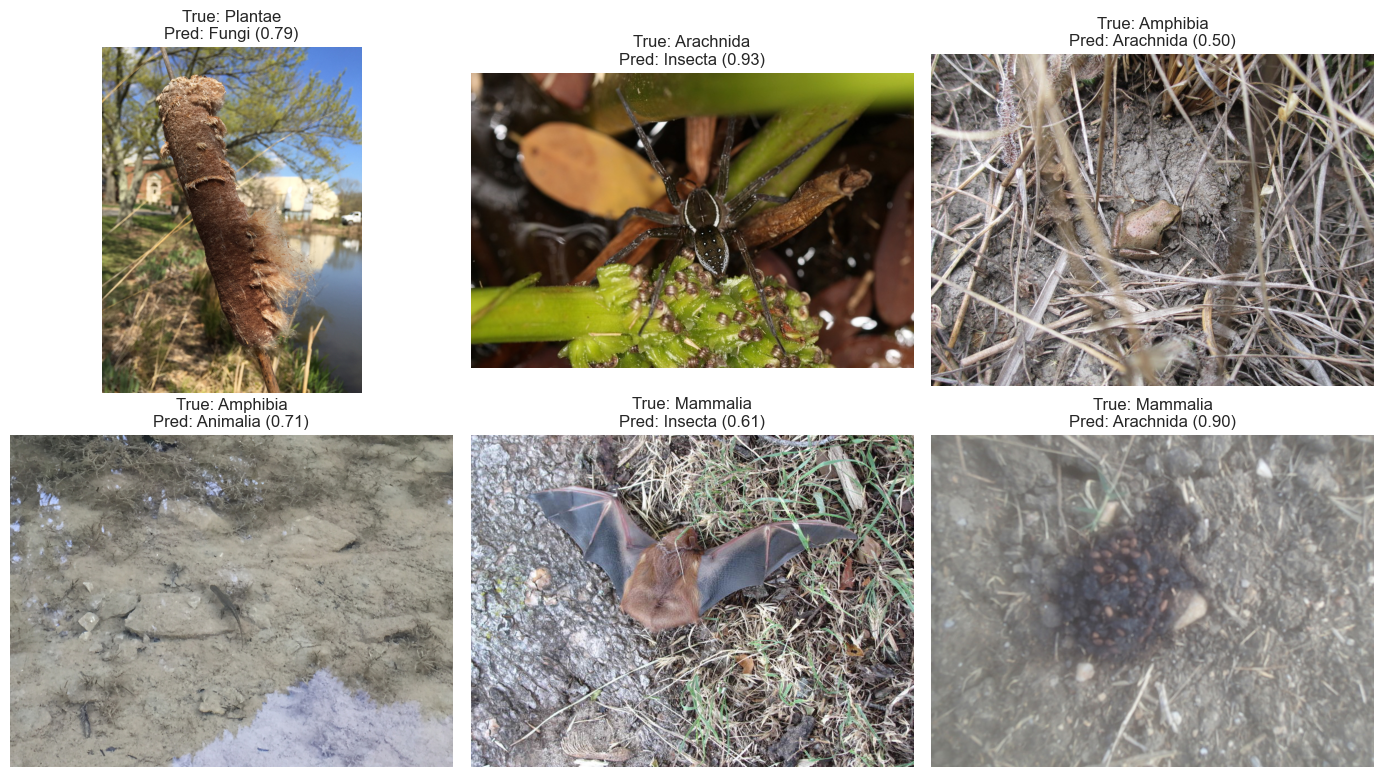

In [ ]:
# Tìm correct và incorrect predictions
correct_mask = all_predictions == all_targets
incorrect_mask = all_predictions != all_targets

print(f"Total predictions: {len(all_predictions)}")
print(f"Correct predictions: {correct_mask.sum()} ({100*correct_mask.sum()/len(all_predictions):.2f}%)")
print(f"Incorrect predictions: {incorrect_mask.sum()} ({100*incorrect_mask.sum()/len(all_predictions):.2f}%)")

# Hiển thị một số incorrect predictions
incorrect_indices = np.where(incorrect_mask)[0]

if len(incorrect_indices) > 0:
    # Lấy dataset mà không transform để hiển thị ảnh gốc
    raw_test_dataset = TestImageDataset(
        csv_path=temp_csv_path,  # Use filtered CSV
        image_dir=str(TEST_DIR),
        transform=None,  # Không transform
        class_to_idx=class_to_idx
    )
    
    # Lấy indices của incorrect predictions
    sample_incorrect = np.random.choice(incorrect_indices, size=min(6, len(incorrect_indices)), replace=False)
    
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    
    for idx, ax_idx in enumerate(axes.flat):
        test_idx = sample_incorrect[idx]
        image, true_label = raw_test_dataset[test_idx]
        predicted_label = all_predictions[test_idx]
        confidence = all_probabilities[test_idx][predicted_label]
        
        ax_idx.imshow(image)
        ax_idx.set_title(f"True: {class_names[true_label]}\nPred: {class_names[predicted_label]} ({confidence:.2f})")
        ax_idx.axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("Không có incorrect predictions!")

### 21. Model Summary

In [ ]:
print("\n" + "="*80)
print("MODEL 2: VISION TRANSFORMER (ViT) - SUMMARY")
print("="*80)
print(f"\nModel Architecture: Vision Transformer Base (ViT-Base-Patch16-224)")
print(f"Input Size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Patch Size: {PATCH_SIZE}x{PATCH_SIZE}")
print(f"Number of Classes: {num_classes}")
print(f"Total Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"\nTraining Configuration:")
print(f"  - Optimizer: AdamW")
print(f"  - Learning Rate: {LEARNING_RATE}")
print(f"  - Weight Decay: {WEIGHT_DECAY}")
print(f"  - Loss Function: CrossEntropyLoss (label_smoothing=0.1)")
print(f"  - Scheduler: CosineAnnealingLR")
print(f"  - Batch Size: {BATCH_SIZE}")
print(f"  - Number of Epochs: {NUM_EPOCHS}")
print(f"\nTraining Data:")
print(f"  - Total training samples: {len(train_dataset)}")
print(f"  - Total test samples: {len(test_dataset)}")
print(f"\nResults:")
print(f"  - Best validation accuracy: {best_val_accuracy:.4f}")
print(f"  - Final test accuracy: {test_accuracy:.4f}")
print(f"  - Final test loss: {test_loss:.4f}")
print(f"\nModel saved at: {MODEL_SAVE_PATH}")
print("="*80)


MODEL 2: VISION TRANSFORMER (ViT) - SUMMARY

Model Architecture: Vision Transformer Base (ViT-Base-Patch16-224)
Input Size: 224x224
Patch Size: 16x16
Number of Classes: 9
Total Parameters: 85,805,577

Training Configuration:
  - Optimizer: AdamW
  - Learning Rate: 0.0001
  - Weight Decay: 0.0001
  - Loss Function: CrossEntropyLoss (label_smoothing=0.1)
  - Scheduler: CosineAnnealingLR
  - Batch Size: 16
  - Number of Epochs: 20

Training Data:
  - Total training samples: 2994
  - Total test samples: 1800

Results:
  - Best validation accuracy: 0.7728
  - Final test accuracy: 0.7706
  - Final test loss: 1.1769

Model saved at: best_model_vit.pth


### 22. So sánh Performance: ResNet50 vs Vision Transformer
(Sau khi chạy DL_ResNet.ipynb, so sánh kết quả)

In [ ]:
# Tạo comparison summary
comparison_data = {
    'Model': ['ResNet50', 'Vision Transformer (ViT)'],
    'Best Val Accuracy': [0.8385, best_val_accuracy],  # ResNet50 accuracy từ DL_ResNet.ipynb
    'Test Accuracy': [0.8385, test_accuracy],
    'Architecture': ['CNN-based', 'Attention-based'],
    'Transfer Learning': ['✓', '✓']
}

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

print("\n✓ Kết quả so sánh hai mô hình đã được cập nhật!")
print(f"\nResNet50 Test Accuracy: {0.8385:.4f}")
print(f"Vision Transformer Test Accuracy: {test_accuracy:.4f}")

,Model,Best Val Accuracy,Test Accuracy,Architecture,Transfer Learning
0,ResNet50,0.838500,0.838500,CNN-based,✓
1,Vision Transformer (ViT),0.772778,0.770556,Attention-based,✓



✓ Kết quả so sánh hai mô hình đã được cập nhật!

ResNet50 Test Accuracy: 0.8385
Vision Transformer Test Accuracy: 0.7706
